In [52]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm

%matplotlib inline

## Считаем данные соревнования от MTS по RecSys

Датасет можно скачать отсюда: [ссылка](https://github.com/MobileTeleSystems/RecTools/tree/main/datasets/KION)

In [54]:
df = pd.read_csv('../../interactions.csv')
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [55]:
df.user_id.nunique(), df.item_id.nunique()

(962179, 15706)

In [56]:
df.last_watch_dt.min(), df.last_watch_dt.max()

('2021-03-13', '2021-08-22')

In [57]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
4928348,742778,15997,2,10785,100.0
1564128,1003442,16087,92,10810,100.0
3424450,407408,10073,153,4054,54.0
1104357,1059779,5051,125,81876,100.0
530255,579325,7033,161,7327,100.0


## Popular bias

<Axes: xlabel='index'>

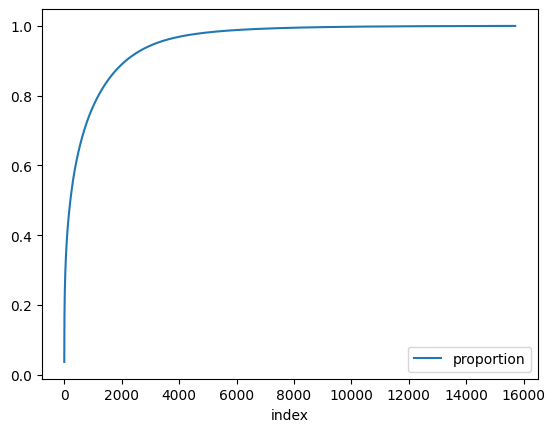

In [58]:
g = df.item_id.value_counts(True).cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

<Axes: xlabel='index'>

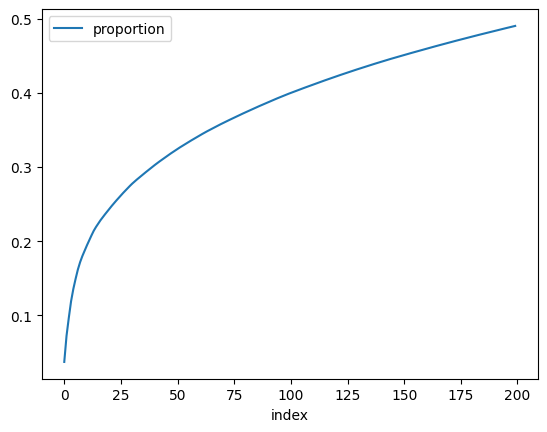

In [59]:
g = df.item_id.value_counts(True)[:200].cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

## Популярность айтема по времени

<Axes: >

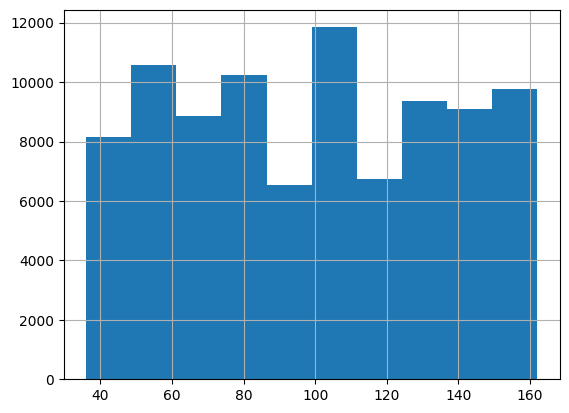

In [60]:
popular_items = df.item_id.value_counts()[:300].index.tolist()

sampled_id = np.random.choice(popular_items)

interactions = df.loc[df.item_id==sampled_id].copy()
interactions.last_watch_dt.hist()

In [61]:
temp = df.groupby('item_id').agg({'last_watch_dt':'max'}).reset_index()
temp = temp.loc[temp.item_id.isin(popular_items)].copy()
temp = temp.sort_values(by='last_watch_dt')
temp.head()

,item_id,last_watch_dt
6751,7107,87
8359,8801,140
11826,12463,141
4486,4716,141
14,14,162


<Axes: >

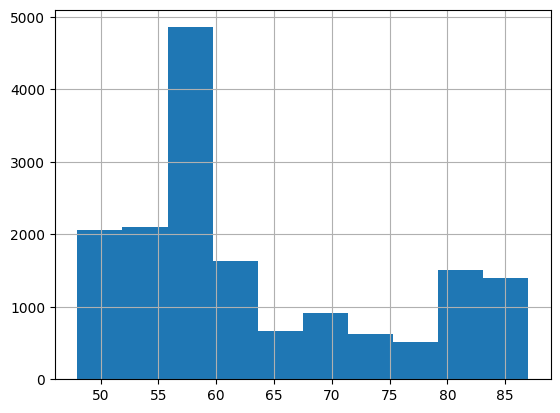

In [62]:
interactions = df.loc[df.item_id==7107].copy()
interactions.last_watch_dt.hist()

этот айтем не встретится в тесте скорее всего, хоть он и популярный

## Сделаем протокол тестирования

<Axes: >

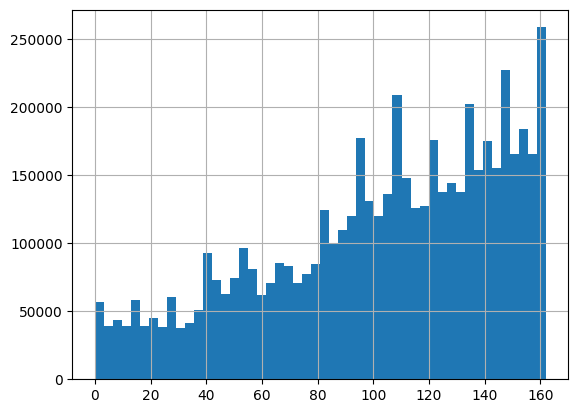

In [63]:
df.last_watch_dt.hist(bins=50)

In [66]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [67]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

## Теперь переведем к соединенному датасету все

In [68]:
n_users = 5000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users


In [69]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
27,841859,3935,94,8862,100.0
47,163922,1931,45,155,0.0
69,804607,5220,120,171,0.0
241,588619,9728,149,9651,100.0
440,104440,1204,147,3826,10.0


In [70]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id, 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

,user_id,train_interactions
0,3,"[(2657, 82), (3734, 131), (9728, 132), (10440,..."
1,866,"[(4582, 35), (6948, 35), (15212, 50), (6645, 6..."
2,900,"[(14741, 71), (7582, 136), (8639, 136), (7444,..."
3,1061,"[(12228, 118)]"
4,1192,"[(4740, 140)]"


In [71]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,3,"[(2657, 82), (3734, 131), (9728, 132), (10440,...","[(142, 153), (10240, 156), (965, 156), (47, 15..."
1,866,"[(4582, 35), (6948, 35), (15212, 50), (6645, 6...","[(512, 153)]"
2,900,"[(14741, 71), (7582, 136), (8639, 136), (7444,...","[(10440, 160), (14488, 160)]"
3,1061,"[(12228, 118)]","[(9728, 161)]"
4,1192,"[(4740, 140)]","[(10440, 157)]"


In [72]:
def ndcg_metric(gt_items, predicted):
    
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)),
                  dtype=np.float64)


def recall_metric(gt_items, predicted):
    
    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / min(n_gt, len(gt_items))



def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return {'ndcg':np.mean([x[0] for x in metric_values]),
            'recall':np.mean([x[1] for x in metric_values])}
            


In [20]:
gt = [1, 42, 3461, 572, 234]
preds = [1]

recall_metric(gt, preds)

0.2

In [73]:
def get_metrics(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return metric_values
        

## Построим EASE

In [74]:
item2id = {k: v for v, k in enumerate(train_df.item_id.unique())}
user2id = {k:v for v, k in enumerate(train_df.user_id.unique())}

id2item = {k:v for v, k in item2id.items()}
id2user = {k:v for v, k in user2id.items()}

train_df['user_id'] = train_df.user_id.apply(lambda x: user2id[x])
train_df['item_id'] = train_df.item_id.apply(lambda x: item2id[x])

train_df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
4132757,5,2653,60,315,6.0
4686715,325,4693,119,5919,100.0
4964370,174,453,35,5648,95.0
2073565,295,167,83,137,0.0
171167,1269,94,55,2513,49.0


In [75]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(train_df.shape[0]), (train_df['user_id'], train_df['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<5000x5362 sparse matrix of type '<class 'numpy.float64'>'
	with 61038 stored elements in COOrdinate format>

In [76]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole

def fit_ease(X, reg_weight=2000):
    
    # gram matrix
    G = X.T @ X

    # add reg to diagonal
    G += reg_weight * sps.identity(G.shape[0])

    # convert to dense because inverse will be dense
    G = G.todense()

    # invert. this takes most of the time
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    # zero out diag
    np.fill_diagonal(B, 0.)
    
    return B

w = fit_ease(matrix)

CPU times: user 18.6 s, sys: 982 ms, total: 19.6 s
Wall time: 4.47 s


In [77]:
w.shape

(5362, 5362)

In [78]:
def get_preds(x, item2id, id2item):

    user_items = [t[0] for t in x]
    encoded = [item2id[t] for t in user_items if t in item2id]

    # Составляем вектор интеракций человека
    vector = np.zeros(len(item2id)) # n_items
    vector[encoded] = 1

    vector = sps.csr_matrix(vector)

    preds = np.array(vector.dot(w))[0]#.toarray()
    preds[encoded==1] = -np.inf # n_items

    items_final = np.argsort(-preds)
    decoded = [(id2item[t], preds[t]) for t in items_final][:40]
    
    return decoded


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item))
joined.head()

,user_id,train_interactions,test_interactions,ease_preds
0,3,"[(2657, 82), (3734, 131), (9728, 132), (10440,...","[(142, 153), (10240, 156), (965, 156), (47, 15...","[(15297, 0.45383000830619924), (10440, 0.37921..."
1,866,"[(4582, 35), (6948, 35), (15212, 50), (6645, 6...","[(512, 153)]","[(10440, 0.14185600941085075), (9728, 0.136894..."
2,900,"[(14741, 71), (7582, 136), (8639, 136), (7444,...","[(10440, 160), (14488, 160)]","[(9728, 0.021571291534987096), (3734, 0.019953..."
3,1061,"[(12228, 118)]","[(9728, 161)]","[(9728, 0.005491556608848235), (15297, 0.00383..."
4,1192,"[(4740, 140)]","[(10440, 157)]","[(13865, 0.02029121944926348), (10440, 0.01739..."


In [79]:
from tqdm import tqdm

new_ds = []
for row in tqdm(joined.itertuples()):
    for rec in row.ease_preds:
        new_ds.append((row.user_id, rec[0], rec[1], 1 if rec[0] in set(row.test_interactions[0]) else 0, len(row.train_interactions)))

new_ds = pd.DataFrame(new_ds, columns = ['user_id', 'item_id', 'score', 'label', 'num_intearctions'])
new_ds.label.mean()

5000it [00:00, 22389.06it/s]


0.00736

In [80]:
new_ds.label.sum()

1472

In [81]:
new_ds.sample(5)

,user_id,item_id,score,label,num_intearctions
8933,49748,6809,0.147364,0,38
27452,157004,4457,0.076812,0,18
58450,330479,4151,0.054581,0,21
106777,590832,47,0.001614,0,1
106465,589760,4495,0.018484,0,3


In [82]:
from sklearn.metrics import roc_auc_score as auc

auc(new_ds['label'], new_ds['score'])

0.618157165611181

скачаем признаки https://ods.ai/competitions/competition-recsys-21/data

In [83]:
users = pd.read_csv('../../users.csv')
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [84]:
items = pd.read_csv('../../items.csv')
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [85]:
bdf = new_ds.merge(users).merge(items[['content_type', 'release_year','genres', 'age_rating', 'item_id']])
bdf['release_year'] = bdf['release_year'].fillna('-1').astype(int)
bdf.sample(5)

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating
18319,955529,3734,0.381326,0,145,age_35_44,income_20_40,М,0,film,2021,комедии,16.0
147346,16657,4718,0.029664,0,10,age_35_44,income_20_40,М,0,film,2009,"драмы, мультфильм, приключения, комедии",0.0
95475,510129,14431,0.021166,0,5,age_35_44,income_40_60,Ж,1,film,2021,"ужасы, триллеры, мелодрамы",16.0
108376,306650,4475,0.015937,0,6,age_35_44,income_40_60,Ж,1,film,2006,"спорт, мультфильм, комедии",6.0
163090,579976,15651,0.001409,0,1,age_25_34,income_20_40,Ж,1,film,2016,"фантастика, мелодрамы, комедии",18.0


In [86]:
for cat in ['age','income','sex','content_type']:
    bdf[cat] = bdf[cat].astype("category")
    

In [87]:
from sklearn.model_selection import train_test_split

train_bdf, test_bdf = train_test_split(bdf)


In [88]:
pos = train_bdf.loc[train_bdf.label==1].copy()
neg = train_bdf.loc[train_bdf.label==0].sample(pos.shape[0] * 4)

new_train = pd.concat([pos, neg])

In [89]:
from lightgbm import LGBMClassifier, plot_importance

FEATURES = ['score', 'age','income','sex','content_type', 'release_year','num_intearctions']


fit_params={#"early_stopping_rounds": 35, 
           # "eval_metric": 'auc', 
           #"eval_set": [(test_df[FEATURES], test_df["label"])],
            #'eval_names': ['valid'],
            #'verbose': 5,
           }
clf = LGBMClassifier(max_depth=3, 
                     
                     #max_bin=30,
                     #boosting_type='dart',
                     random_state=0, 
                    # metric='None', 
                     n_estimators=100,
                     learning_rate=0.1,
                     n_jobs=10)
clf.fit(
    X=train_bdf[FEATURES],
    y=train_bdf["label"],
    **fit_params
)

[LightGBM] [Info] Number of positive: 872, number of negative: 121978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000898 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 122850, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007098 -> initscore=-4.940807
[LightGBM] [Info] Start training from score -4.940807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(max_depth=3, n_jobs=10, random_state=0)

In [40]:
test_bdf.age.value_counts()

age
age_25_34     12753
age_35_44     11727
age_45_54      7268
age_18_24      4191
age_55_64      3011
age_65_inf     1764
Name: count, dtype: int64

In [41]:
test_bdf['boosting_preds_new'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

In [91]:

test_bdf['boosting_preds'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

for model_name in ['score','boosting_preds']:
    print(model_name, ": ", auc(test_bdf['label'], test_bdf[model_name])) 
    


score :  0.6031736172847346
boosting_preds :  0.6951884366268734


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

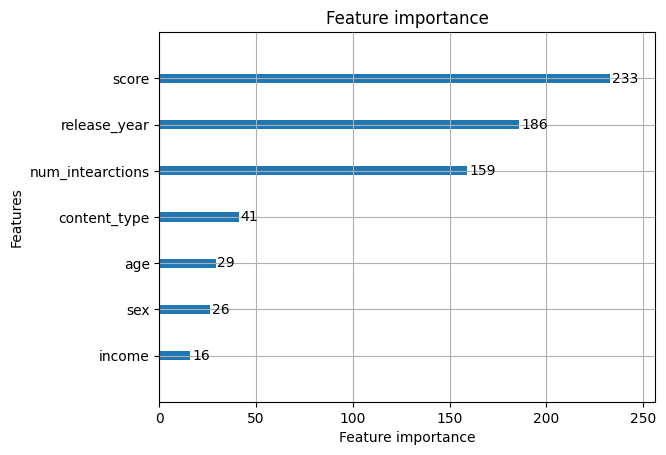

In [92]:
plot_importance(clf)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


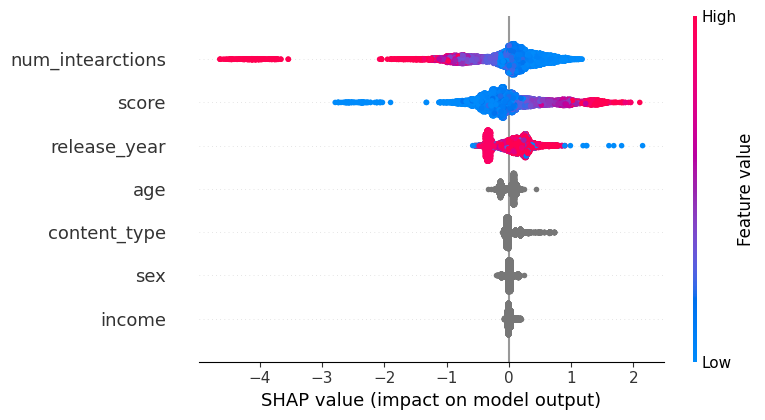

In [93]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(test_bdf[FEATURES][:10000])
shap.summary_plot(shap_values[1], test_bdf[FEATURES][:10000])

In [94]:
from sklearn.metrics import ndcg_score

In [95]:
def get_recall(x, col, at=3):

    if x.label.sum():
        return x.sort_values(by=col, ascending=False)[:at].label.sum() / x.label.sum()
        
    return 0
    
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'score', at=10)).mean()

0.07228327228327229

In [96]:
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'boosting_preds', at=10)).mean()

0.07179487179487179

In [100]:
test_bdf.loc[test_bdf.user_id==122830].sort_values(by='boosting_preds')

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating,boosting_preds
35745,122830,8636,0.068640,0,26,age_18_24,income_20_40,Ж,0,film,2021,"драмы, спорт",6.0,0.003563
28891,122830,142,0.069919,0,26,age_18_24,income_20_40,Ж,0,film,2020,"драмы, триллеры",16.0,0.003613
101860,122830,15266,0.065553,0,26,age_18_24,income_20_40,Ж,0,film,2001,"мультфильм, фэнтези, приключения, комедии",6.0,0.004228
126426,122830,14317,0.050389,0,26,age_18_24,income_20_40,Ж,0,film,2018,"популярное, фантастика, триллеры, боевики, ужасы",16.0,0.004566
101202,122830,334,0.052067,0,26,age_18_24,income_20_40,Ж,0,film,2012,"мультфильм, фэнтези, приключения, комедии",6.0,0.005007
134261,122830,7582,0.068967,0,26,age_18_24,income_20_40,Ж,0,film,2019,"фэнтези, мультфильм, музыкальные",6.0,0.005239
102662,122830,11985,0.068947,0,26,age_18_24,income_20_40,Ж,0,film,2019,"мультфильм, фэнтези, комедии",6.0,0.005239
104170,122830,11749,0.082727,0,26,age_18_24,income_20_40,Ж,0,film,2018,"фантастика, мультфильм, приключения",6.0,0.006984
105803,122830,3182,0.096171,0,26,age_18_24,income_20_40,Ж,0,film,2018,"мультфильм, приключения, фантастика, семейное,...",6.0,0.007667
